In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [67]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [68]:
len(df)

9000

In [220]:
train_data = df.head(8000)
test_data = df.tail(1000)

In [221]:
train_data.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid4,169.0,172.0,173.0,172.0,173.0,172.0,174.0
1,odroid4,169.0,214.0,135.0,172.0,175.0,174.0,173.0
2,odroid3,166.0,172.0,168.0,172.0,172.0,173.0,165.0
3,rpi_8b,64.1,62.9,62.3,60.7,62.9,60.9,60.4
4,rpi-8d,19.3,18.6,43.4,1736.3,20.3,21.3,19.4


In [222]:
predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
y_pred = predictor.predict(test_data)
y_pred_proba = predictor.predict_proba(test_data)
results = predictor.evaluate(test_data)

No path specified. Models will be saved in: "AutogluonModels/ag-20240913_054120"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #44-Ubuntu SMP PREEMPT_DYNAMIC Tue Aug 13 13:35:26 UTC 2024
CPU Count:          12
Memory Avail:       19.92 GB / 23.34 GB (85.3%)
Disk Space Avail:   253.86 GB / 341.37 GB (74.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240913_054120"
Train Data Rows:    8000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid4', 'odroid3', 'rpi_8b', 'rpi-8d', 'rpi_8c', 'odroid2', 'odroid1', 'rpi-8a', 'rpi-4a']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type para

# Synthetic Adversarial Example - Naive

In [12]:
test_data.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
8000,rpi_8b,63.2,62.2,61.2,60.9,59.8,60.1,60.9
8001,odroid4,170.0,172.0,175.0,173.0,172.0,173.0,173.0
8002,rpi-4a,16.1,19.5,784.9,628.7,19.5,430.8,20.1
8003,rpi-8d,18.9,14.9,1388.9,15.9,17.9,17.8,17.6
8004,rpi_8b,62.8,62.0,61.8,60.8,59.8,61.2,60.6


In [46]:
naive_results = pd.DataFrame(columns=['Interval', 'accuracy', 'balanced_accuracy', 'mcc'])
for i in range(1,26):
    noise = np.random.uniform(-i, i, size=(len(test_data), len(test_data.columns) - 1))
    naive_adversary = test_data.iloc[:, 1:] + noise
    naive_adversary = np.round(naive_adversary, decimals=1)
    naive_adversary['label'] = test_data.iloc[:, :1]
    y_pred = predictor.predict(naive_adversary)
    y_pred_proba = predictor.predict_proba(naive_adversary)
    results = predictor.evaluate(naive_adversary)
    new_results = {'Interval':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    naive_results.loc[len(naive_results)] = (new_results)

In [47]:
naive_results

,Interval,accuracy,balanced_accuracy,mcc
0,1,0.877,0.877645,0.862901
1,2,0.851,0.851777,0.838881
2,3,0.841,0.842079,0.829983
3,4,0.789,0.790128,0.774217
4,5,0.763,0.764352,0.746099
5,6,0.738,0.738191,0.720581
6,7,0.731,0.730570,0.711513
7,8,0.719,0.717863,0.697458
8,9,0.689,0.686762,0.663780
9,10,0.693,0.691582,0.671022


## Which uniform intervals are able to fool the model?

<Axes: xlabel='Interval', ylabel='value'>

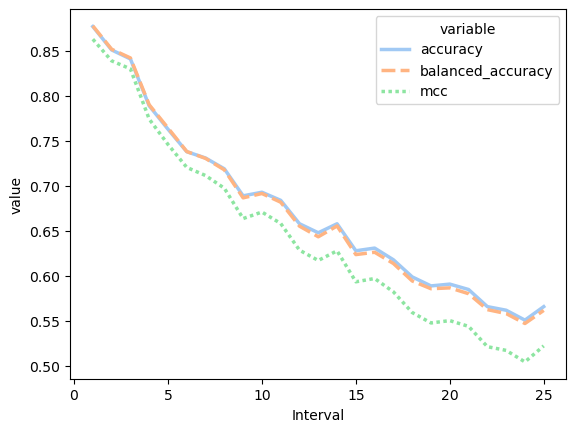

In [48]:
sns.lineplot(data=pd.melt(naive_results, ['Interval']), x='Interval', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

Something between 0.1–2.5 seems to be best, higher divergence tanks accuracy

## How often was the model fooled by the simple uniform noise?

In [310]:
# malicious testing data
# malicious_testing = test_data.head(500)

# malicious_testing1 = malicious_testing.iloc[:125].iloc[:, 1:] + np.random.uniform(-1, 1, size=(125, 7))
# malicious_testing2 = malicious_testing.iloc[125:250].iloc[:, 1:] + np.random.uniform(-2, 2, size=(125, 7))
# malicious_testing3 = malicious_testing.iloc[250:375].iloc[:, 1:] + np.random.uniform(-3, 3, size=(125, 7))
# malicious_testing4 = malicious_testing.iloc[375:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(125, 7))

# malicious_testing = pd.concat([malicious_testing1, malicious_testing2, malicious_testing3, malicious_testing4])
# malicious_testing = np.round(malicious_testing, decimals=1)
# malicious_testing['label'] = test_data.iloc[:, :1]

# y_pred = predictor.predict(naive_adversary)
# y_pred_proba = predictor.predict_proba(naive_adversary)
# results = predictor.evaluate(naive_adversary)

In [311]:
# model_tricked_1 = 0
# model_tricked_2 = 0
# model_tricked_3 = 0
# model_tricked_4 = 0
# for i, (pred, label) in enumerate(zip(y_pred, test_data.head(500).iloc[:, :1].squeeze())):
#     if pred == label:
#         if i < 125:
#             model_tricked_1 += 1
#         elif 125 <= i < 250:
#             model_tricked_2 += 1
#         elif 250 <= i < 375:
#             model_tricked_3 += 1
#         else: 
#             model_tricked_4 += 1

# model_tricked_1 /= 125
# model_tricked_2 /= 125
# model_tricked_3 /= 125
# model_tricked_4 /= 125

tricked_df = pd.DataFrame({'Uniform Value': [1,2,3,4], 'Adversarial Success % (No AD)': [86.4, 88.0, 85.6, 84.8]})

# Training original model to detect uniform noise - Binary Classification (safe/malicious)

## Adversarial Data

In [216]:
naive_results = pd.DataFrame(columns=['Training Size', 'roc_auc', 'f1', 'precision', 'recall',])
for i in np.arange(0.1, 1.1, 0.1):
    i = round(i, 2)

    # malicious training data
    malicious_training = train_data.head(int(4000 *i))
    
    malicious_training1 = malicious_training.iloc[:int(1000*i), 1:] + np.random.uniform(-1, 1, size=(int(1000*i), 7))
    malicious_training2 = malicious_training.iloc[int(1000*i):int(2000*i)].iloc[:, 1:] + np.random.uniform(-2, 2, size=(int(1000*i), 7))
    malicious_training3 = malicious_training.iloc[int(2000*i):int(3000*i)].iloc[:, 1:] + np.random.uniform(-3, 3, size=(int(1000*i), 7))
    malicious_training4 = malicious_training.iloc[int(3000*i):].iloc[:, 1:] + np.random.uniform(-4, 4, size=(int(1000*i), 7))
    
    malicious_training = pd.concat([malicious_training1, malicious_training2, malicious_training3, malicious_training4])
    malicious_training = np.round(malicious_training, decimals=1)
    malicious_training['label'] = test_data.iloc[:, :1]
    malicious_training['label'] = 'malicious'

    # malicious testing data
    malicious_testing = test_data.head(500)
    
    malicious_testing1 = malicious_testing.iloc[:125].iloc[:, 1:] + np.random.uniform(-1, 1, size=(125, 7))
    malicious_testing2 = malicious_testing.iloc[125:250].iloc[:, 1:] + np.random.uniform(-2, 2, size=(125, 7))
    malicious_testing3 = malicious_testing.iloc[250:375].iloc[:, 1:] + np.random.uniform(-3, 3, size=(125, 7))
    malicious_testing4 = malicious_testing.iloc[375:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(125, 7))
    
    malicious_testing = pd.concat([malicious_testing1, malicious_testing2, malicious_testing3, malicious_testing4])
    malicious_testing = np.round(malicious_testing, decimals=1)
    malicious_testing['label'] = test_data.iloc[:, :1]
    malicious_testing['label'] = 'malicious'

    # safe training data
    safe_training = train_data.copy()
    safe_training = safe_training.tail(int(4000*i))
    safe_training['label'] = 'safe'

    # safe testing data
    safe_testing = test_data.copy()
    safe_testing = safe_testing.tail(500)
    safe_testing['label'] = 'safe'

    # combining test/train safe/malicious datasets
    safe_malicious_train = pd.concat([safe_training, malicious_training])
    safe_malicious_test = pd.concat([safe_testing, malicious_testing])

    # training model
    predictor = TabularPredictor(label='label').fit(safe_malicious_train, num_gpus=1, presets='medium_quality')

    # get testing results
    y_pred = predictor.predict(safe_malicious_test)
    y_pred_proba = predictor.predict_proba(safe_malicious_test)
    results = predictor.evaluate(safe_malicious_test)

    new_result = {'Training Size':4000 *i, 'roc_auc':results['roc_auc'], 'f1':results['f1'], 'precision':results['precision'], 'recall':results['recall'] }
    naive_results.loc[len(naive_results)] = new_result

No path specified. Models will be saved in: "AutogluonModels/ag-20240913_051544"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #44-Ubuntu SMP PREEMPT_DYNAMIC Tue Aug 13 13:35:26 UTC 2024
CPU Count:          12
Memory Avail:       19.93 GB / 23.34 GB (85.4%)
Disk Space Avail:   255.28 GB / 341.37 GB (74.8%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240913_051544"
Train Data Rows:    800
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['safe', 'malicious']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binar

[1000]	valid_set's binary_error: 0.23125


	0.7969	 = Validation score   (accuracy)
	0.69s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.8531	 = Validation score   (accuracy)
	0.38s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8031	 = Validation score   (accuracy)
	0.35s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8094	 = Validation score   (accuracy)
	0.28s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8219	 = Validation score   (accuracy)
	3.99s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.7375	 = Validatio

[1000]	valid_set's binary_error: 0.204167


	0.8521	 = Validation score   (accuracy)
	0.99s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


...

	0.8516	 = Validation score   (accuracy)
	1.6s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.8797	 = Validation score   (accuracy)
	0.45s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8375	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8516	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.85	 = Validation score   (accuracy)
	4.46s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.7828	 = Validation 

[1000]	valid_set's binary_error: 0.168056


	0.8528	 = Validation score   (accuracy)
	1.18s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.


[2000]	valid_set's binary_error: 0.15


[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.8833	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8625	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8569	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8514	 = Validation score   (accuracy)
	5.49s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.8028	 = Validation score   (accuracy)
	0.31s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.7917	 = Validation score   (accuracy)
	0.3s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: Neural

## How much data is needed for decent model accuracy?

<Axes: xlabel='Training Size', ylabel='value'>

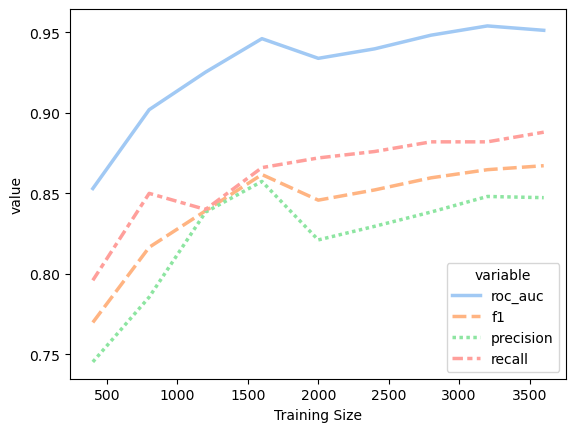

In [217]:
sns.lineplot(data=pd.melt(naive_results, ['Training Size']), x='Training Size', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [325]:
i = 0.5

# malicious training data
malicious_training = train_data.head(int(4000 *i))

malicious_training1 = malicious_training.iloc[:int(1000*i), 1:] + np.random.uniform(-1, 1, size=(int(1000*i), 7))
malicious_training2 = malicious_training.iloc[int(1000*i):int(2000*i)].iloc[:, 1:] + np.random.uniform(-2, 2, size=(int(1000*i), 7))
malicious_training3 = malicious_training.iloc[int(2000*i):int(3000*i)].iloc[:, 1:] + np.random.uniform(-3, 3, size=(int(1000*i), 7))
malicious_training4 = malicious_training.iloc[int(3000*i):].iloc[:, 1:] + np.random.uniform(-4, 4, size=(int(1000*i), 7))

malicious_training = pd.concat([malicious_training1, malicious_training2, malicious_training3, malicious_training4])
malicious_training = np.round(malicious_training, decimals=1)
malicious_training['label'] = test_data.iloc[:, :1]
malicious_training['label'] = 'malicious'

# malicious testing data
malicious_testing = test_data.head(500)

malicious_testing1 = malicious_testing.iloc[:125].iloc[:, 1:] + np.random.uniform(-1, 1, size=(125, 7))
malicious_testing2 = malicious_testing.iloc[125:250].iloc[:, 1:] + np.random.uniform(-2, 2, size=(125, 7))
malicious_testing3 = malicious_testing.iloc[250:375].iloc[:, 1:] + np.random.uniform(-3, 3, size=(125, 7))
malicious_testing4 = malicious_testing.iloc[375:].iloc[:, 1:] + np.random.uniform(-4, 4, size=(125, 7))

malicious_testing = pd.concat([malicious_testing1, malicious_testing2, malicious_testing3, malicious_testing4])
malicious_testing = np.round(malicious_testing, decimals=1)
malicious_testing['label'] = test_data.iloc[:, :1]
malicious_testing['label'] = 'malicious'

# safe training data
safe_training = train_data.copy()
safe_training = safe_training.tail(int(4000*i))
safe_training['label'] = 'safe'

# safe testing data
safe_testing = test_data.copy()
safe_testing = safe_testing.tail(500)
safe_testing['label'] = 'safe'

# combining test/train safe/malicious datasets
safe_malicious_train = pd.concat([safe_training, malicious_training])
safe_malicious_test = pd.concat([safe_testing, malicious_testing])

# training model
predictor = TabularPredictor(label='label').fit(safe_malicious_train, num_gpus=1, presets='medium_quality')

# get testing results
y_pred = predictor.predict(safe_malicious_test)
y_pred_proba = predictor.predict_proba(safe_malicious_test)
results = predictor.evaluate(safe_malicious_test)

No path specified. Models will be saved in: "AutogluonModels/ag-20240913_062602"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #44-Ubuntu SMP PREEMPT_DYNAMIC Tue Aug 13 13:35:26 UTC 2024
CPU Count:          12
Memory Avail:       19.85 GB / 23.34 GB (85.0%)
Disk Space Avail:   253.53 GB / 341.37 GB (74.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240913_062602"
Train Data Rows:    4000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['safe', 'malicious']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['bina

[1000]	valid_set's binary_error: 0.162


[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.882	 = Validation score   (accuracy)
	0.53s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.846	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.85	 = Validation score   (accuracy)
	0.29s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.848	 = Validation score   (accuracy)
	3.0s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.802	 = Validation score   (accuracy)
	0.3s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.794	 = Validation score   (accuracy)
	0.3s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: NeuralNetFastAI 

In [326]:
malicious_testing

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,label
8000,217.7,194.9,434.5,16.4,217.2,199.7,216.1,malicious
8001,165.0,166.0,166.7,165.4,167.0,166.7,166.6,malicious
8002,62.6,62.5,62.6,59.9,59.4,59.0,59.5,malicious
8003,64.0,62.9,61.1,59.7,59.1,60.1,60.1,malicious
8004,169.1,172.0,173.2,175.2,172.6,173.5,173.9,malicious
...,...,...,...,...,...,...,...,...
8495,18.3,18.0,21.2,956.8,18.7,18.9,17.2,malicious
8496,18.3,19.7,771.4,16.3,19.3,19.1,19.6,malicious
8497,163.0,173.0,171.7,170.6,169.7,168.5,162.2,malicious
8498,168.5,191.0,1.1,171.3,13.4,316.3,334.4,malicious


In [351]:
safe_malicious_test.iloc[:, :1].squeeze()

8500         safe
8501         safe
8502         safe
8503         safe
8504         safe
          ...    
8495    malicious
8496    malicious
8497    malicious
8498    malicious
8499    malicious
Name: label, Length: 1000, dtype: object

In [352]:
y_pred

8500         safe
8501         safe
8502         safe
8503         safe
8504         safe
          ...    
8495         safe
8496         safe
8497    malicious
8498    malicious
8499    malicious
Name: label, Length: 1000, dtype: object

In [368]:
y_pred = predictor.predict(safe_malicious_test)
y_pred_proba = predictor.predict_proba(safe_malicious_test)
results = predictor.evaluate(safe_malicious_test)

model_tricked_1 = 0
model_tricked_2 = 0
model_tricked_3 = 0
model_tricked_4 = 0
for i, (pred, label) in enumerate(zip(y_pred, safe_malicious_test.iloc[:, :1].squeeze())):
    if pred=='safe' and label=='malicious':
        if i < 625:
            model_tricked_1 += 1
        elif 125 <= i < 750:
            model_tricked_2 += 1
        elif 750 <= i < 875:
            model_tricked_3 += 1
        else: 
            model_tricked_4 += 1

model_tricked_1 /= 125
model_tricked_2 /= 125
model_tricked_3 /= 125
model_tricked_4 /= 125

/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))
/home/zac/mini

In [373]:
tricked_df['Adversarial Success % (AD)'] = [model_tricked_1 *100, model_tricked_2*100, model_tricked_3*100, model_tricked_4*100]

In [374]:
tricked_df

,Uniform Value,Adversarial Success % (No AD),Adversarial Success % (AD)
0,1,86.4,22.4
1,2,88.0,22.4
2,3,85.6,8.0
3,4,84.8,11.2


<Axes: xlabel='Uniform Value', ylabel='value'>

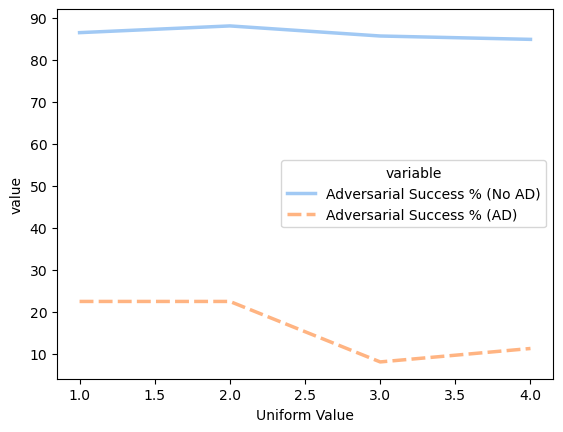

In [377]:
sns.lineplot(data=pd.melt(tricked_df, ['Uniform Value']), x='Uniform Value', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)